# Injecting an arbitrary MBHB into arbitrary gaps

`gaplike` is not tied to the source used in the paper. The paper's `core.py`
only *pins* one configuration so its figures are reproducible; the package
itself takes **any** MBHB parameters, and in fact any parametrization and any
waveform approximant.

This notebook shows, in order:

1. how to inject an MBHB with parameters of your choosing — and how to swap
   the parametrization itself, or the approximant;
2. a menu of **gap configurations** (long tapered gaps, hourly short gaps, a
   periodic comb, Poisson gaps, or your own intervals) and what each does to
   the duty cycle and to the recoverable SNR;
3. a complete joint 13-parameter inference setup — likelihood, priors,
   walkers, sampler — **ready but not launched**: the sampling cell is left
   commented at the end.

Requirements: `gaplike[pe]` plus
[lisabeta](https://gitlab.in2p3.fr/marsat/lisabeta) for the MBHB waveform.
Sections 2 and 3 work with any waveform you plug in.

In [14]:
import time
import numpy as np
import matplotlib.pyplot as plt

import gaplike as gl

rng = np.random.default_rng(11)

# ---- analysis segment ------------------------------------------------------
DT         = 15.0                      # cadence [s]  (Nyquist 1/30 Hz)
HOURS      = 12.0                      # segment length [h]
N          = int(round(HOURS * 3600 / DT))
T_OBS      = N * DT
F_LO, F_HI = 1.0e-4, 3.1e-2            # analysis band [Hz]
NCH        = 2                         # TDI channels A, E

th = np.arange(N) * DT / 3600.0        # time grid [h]
print(f"N = {N} samples, T = {HOURS:g} h, band = [{F_LO:g}, {F_HI:g}] Hz")

N = 2880 samples, T = 12 h, band = [0.0001, 0.031] Hz


## 1. An MBHB with the parameters *you* choose

`gl.waveform.lisabeta_mbhb_ae` returns a `Waveform` object wrapping the (A, E)
TDI-2 response, summed over all modes of the approximant. It consumes an
11-component vector:

| # | name | meaning | # | name | meaning |
|---|---|---|---|---|---|
| 0 | `Mtot` | total mass [M<sub>☉</sub>] | 6 | `phi` | reference phase [rad] |
| 1 | `q` | mass ratio m₁/m₂ ≥ 1 | 7 | `lambda` | ecliptic longitude [rad] |
| 2 | `chi1` | dimensionless spin 1 | 8 | `beta` | ecliptic latitude [rad] |
| 3 | `chi2` | dimensionless spin 2 | 9 | `psi` | polarization [rad] |
| 4 | `log10 dL` | luminosity distance [Gpc] | 10 | `tc_frac` | merger time / T<sub>obs</sub> |
| 5 | `iota` | inclination [rad] | | | |

Angles are in the L-frame. Element 10 is applied as the frequency-domain
phase `exp(-2πi f · tc_frac · T_obs)`, common to every mode, so it simply
**slides the merger along the segment**.

In [15]:
SIG_NAMES = ["Mtot", "q", "chi1", "chi2", "log10dL",
             "iota", "phi", "lambda", "beta", "psi", "tc_frac"]
NSIG = len(SIG_NAMES)

def theta_of(Mtot=5.0e6, q=3.0, chi1=0.4, chi2=0.2, dL_Gpc=15.0,
             iota=1.1, phi=0.3, lam=2.1, beta=-0.4, psi=0.7, tc_frac=0.5):
    # 'lam' is the ecliptic longitude ('lambda' is a Python keyword).
    # Change any of these -- nothing in gaplike constrains them.
    return np.array([Mtot, q, chi1, chi2, np.log10(dL_Gpc),
                     iota, phi, lam, beta, psi, tc_frac])

wf = gl.waveform.lisabeta_mbhb_ae(N, DT, F_LO, F_HI)   # IMRPhenomHM, TDI2 A/E

theta_true = theta_of()                                # <<< your source here
h = wf.td(theta_true)                                  # (2, N) time domain

print("injected:", ", ".join(f"{k}={v:.4g}" for k, v in zip(SIG_NAMES, theta_true)))
print(f"peak of |h_A| at t = {th[np.argmax(np.abs(h[0]))]:.2f} h of {HOURS:g} h")

injected: Mtot=5e+06, q=3, chi1=0.4, chi2=0.2, log10dL=1.176, iota=1.1, phi=0.3, lambda=2.1, beta=-0.4, psi=0.7, tc_frac=0.5
peak of |h_A| at t = 6.02 h of 12 h


If the merger does not land where you want it, change `tc_frac`: it shifts
the signal by `tc_frac × T_obs`. The print above is the check — a merger that
falls outside the segment gives an SNR near zero and nothing downstream will
make sense.

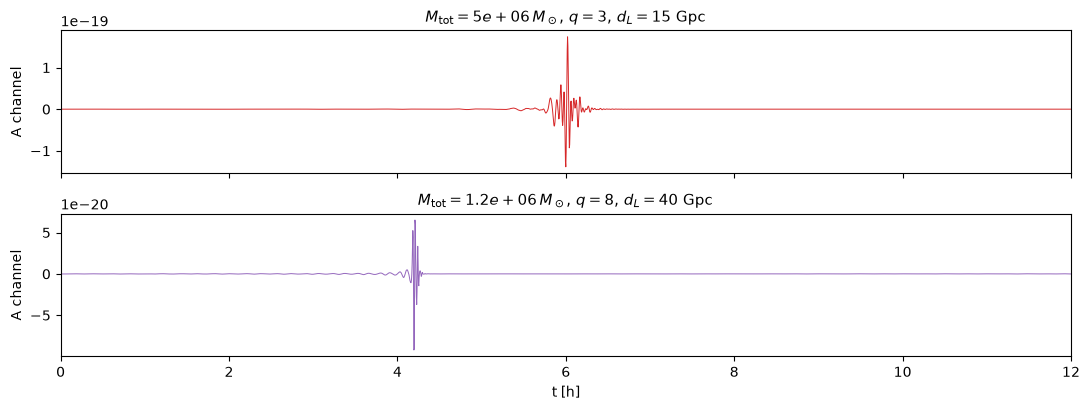

In [16]:
# a completely different source, to make the point
theta_alt = theta_of(Mtot=1.2e6, q=8.0, chi1=-0.6, chi2=0.9,
                     dL_Gpc=40.0, iota=0.2, tc_frac=0.35)
h_alt = wf.td(theta_alt)

fig, ax = plt.subplots(2, 1, figsize=(11, 4.2), sharex=True)
ax[0].plot(th, h[0], lw=0.7, color="tab:red")
ax[0].set_ylabel("A channel")
ax[0].set_title(rf"$M_{{\rm tot}}={theta_true[0]:.2g}\,M_\odot$, $q={theta_true[1]:.3g}$, "
                rf"$d_L={10**theta_true[4]:.3g}$ Gpc", fontsize=11)
ax[1].plot(th, h_alt[0], lw=0.7, color="tab:purple")
ax[1].set_ylabel("A channel"); ax[1].set_xlabel("t [h]"); ax[1].set_xlim(0, HOURS)
ax[1].set_title(rf"$M_{{\rm tot}}={theta_alt[0]:.2g}\,M_\odot$, $q={theta_alt[1]:.3g}$, "
                rf"$d_L={10**theta_alt[4]:.3g}$ Gpc", fontsize=11)
plt.tight_layout()

### Swapping the parametrization, or the approximant

The 11-vector above is only the *default* map into lisabeta
(`gl.waveform.default_mbhb_params`). The `to_params` argument replaces it, so
you can sample in whatever coordinates you like without touching the package
— chirp mass and symmetric mass ratio, say. `wf_kw` goes straight to lisabeta,
so the approximant and TDI generation are yours too.

In [17]:
def mc_eta_to_params(x):
    # x = (Mc, eta, chi1, chi2, log10dL, iota, phi, lambda, beta, psi, tc_frac)
    Mc, eta = x[0], x[1]
    Mtot = Mc / eta**0.6
    q = (1.0 - 2*eta + np.sqrt(max(1.0 - 4*eta, 0.0))) / (2*eta)
    return gl.waveform.default_mbhb_params(np.concatenate([[Mtot, q], x[2:]]))

wf_mc = gl.waveform.lisabeta_mbhb_ae(N, DT, F_LO, F_HI, to_params=mc_eta_to_params)

# and a different approximant / no higher modes
wf_22 = gl.waveform.lisabeta_mbhb_ae(
    N, DT, F_LO, F_HI,
    wf_kw=dict(TDI="TDI2AET", TDIrescaled=False, approximant="IMRPhenomD"))

# check the reparametrization is consistent with the default one
Mtot, q = theta_true[0], theta_true[1]
eta = q / (1 + q)**2
x_mc = np.concatenate([[Mtot * eta**0.6, eta], theta_true[2:]])
print("max |h(Mc,eta) - h(Mtot,q)| / max|h| =",
      np.max(np.abs(wf_mc.td(x_mc) - h)) / np.max(np.abs(h)))

max |h(Mc,eta) - h(Mtot,q)| / max|h| = 0.0


## 2. Gap configurations

Every builder in `gl.gaps` returns a boolean **mask** (`True` = observed).
Below, five patterns spanning the regimes of the paper. Mix them freely — a
mask is just an array, so `mask_A & mask_B` is a valid pattern too.

In [5]:
CONFIGS = {}

# reference: nothing removed
CONFIGS["no gaps"] = np.ones(N, bool)

# A: two long gaps, Planck-tapered edges (antenna repointing, TM release)
gate_A = gl.gaps.gate_from_gaps([(3.0, 1.0), (8.0, 1.0)], taper=0.3, t=th)
CONFIGS["A: 2 long gaps"] = gl.gaps.mask_from_gate(gate_A)

# B: eleven short gaps, one per hour, 9 min each
CONFIGS["B: hourly short"] = gl.gaps.mask_from_intervals(
    N, DT, [(k * 3600.0, k * 3600.0 + 9 * 60) for k in range(1, 12)])

# C: drastic periodic comb -- 10 of every 50 samples (150 s out of 750 s)
CONFIGS["C: comb 20%"] = gl.gaps.periodic_mask(N, 10, 50)

# D: Poisson gaps -- 40 per day on average, 10 min each, jittered
CONFIGS["D: random"] = gl.gaps.random_mask(N, DT, rate_per_day=40,
                                           duration_s=600,
                                           duration_jitter_s=120, rng=3)

for name, m in CONFIGS.items():
    ints = gl.gaps.gap_intervals(m, DT)
    print(f"{name:16s} duty {gl.gaps.duty_cycle(m):5.1%}   "
          f"{len(ints):2d} gap(s)   m = {int(np.sum(m)):4d} observed samples")

no gaps          duty 100.0%    0 gap(s)   m = 2880 observed samples
A: 2 long gaps   duty 83.3%    2 gap(s)   m = 2398 observed samples
B: hourly short  duty 86.2%   11 gap(s)   m = 2484 observed samples
C: comb 20%      duty 79.9%   58 gap(s)   m = 2300 observed samples
D: random        duty 84.8%   10 gap(s)   m = 2443 observed samples


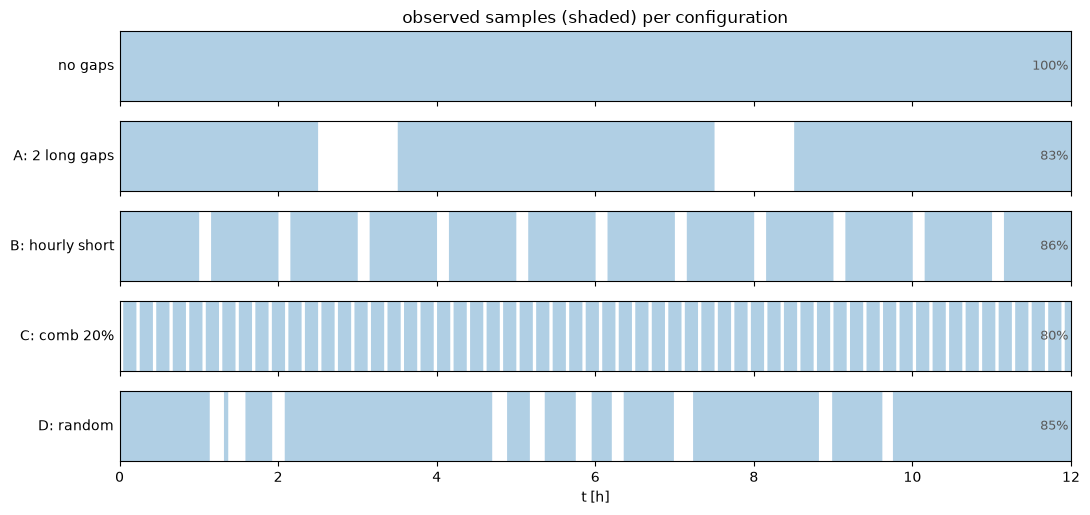

In [6]:
fig, axes = plt.subplots(len(CONFIGS), 1, figsize=(11, 1.05 * len(CONFIGS)),
                         sharex=True)
for ax, (name, m) in zip(axes, CONFIGS.items()):
    ax.fill_between(th, 0, np.asarray(m, float), step="mid",
                    color="tab:blue", alpha=0.35, lw=0)
    ax.set_ylabel(name, rotation=0, ha="right", va="center", fontsize=10)
    ax.set_yticks([]); ax.set_ylim(0, 1); ax.set_xlim(0, HOURS)
    ax.text(0.997, 0.5, f"{gl.gaps.duty_cycle(m):.0%}", transform=ax.transAxes,
            ha="right", va="center", fontsize=9, color="0.35")
axes[-1].set_xlabel("t [h]")
axes[0].set_title("observed samples (shaded) per configuration", fontsize=12)
plt.tight_layout()

### What each pattern costs in SNR

The optimal SNR of the injection under gaps is
`SNR² = hᵀ Σ_OO⁻¹ h`, summed over channels — the same quadratic form the
likelihood needs. Computed here with the **matrix-free CG solver**, which
needs no factorization at all, so this loop is cheap even though it covers
five different covariances.

In [7]:
comps = list(gl.psd.lisa_tdi2_ae().values())        # [S_tm(f), S_oms(f)]

print(f"{'configuration':16s} {'duty':>6s} {'m':>6s} {'SNR':>8s} {'CG iters':>9s}")
snr = {}
for name, m in CONFIGS.items():
    obs = np.flatnonzero(m)
    rcg = gl.RestrictedCG(m, comps, DT, rtol=1e-10)
    quad, iters = rcg.quad_form((0.0, 0.0), h[:, obs])   # lam = 0: reference noise
    snr[name] = np.sqrt(quad)
    print(f"{name:16s} {gl.gaps.duty_cycle(m):5.1%} {obs.size:6d} "
          f"{snr[name]:8.1f} {iters[0]:9d}")

configuration      duty      m      SNR  CG iters
no gaps          100.0%   2880   2402.3         1
A: 2 long gaps   83.3%   2398   2400.2        34
B: hourly short  86.2%   2484   1803.8       136
C: comb 20%      79.9%   2300   1897.2       454
D: random        84.8%   2443   1786.5       176


The iteration count in the last column is worth a second look. With no gaps
the preconditioner *is* the covariance, and CG converges in a single step;
every extra iteration is a direct measure of how far the gap pattern pushes
the restricted covariance away from stationarity. Two long gaps barely
register, the comb costs five hundred iterations — which is the same ordering
you will find in the widths of the posteriors.

## 3. Data, and the inference setup

Pick one configuration, add a noise realization, and build everything the
sampler needs. Two exact likelihood tiers are set up side by side — the
time-domain one (no window anywhere) and the dense windowed
frequency-domain one — so you can run either.

In [8]:
CONFIG = "C: comb 20%"                 # <<< pick any key from CONFIGS

mask  = CONFIGS[CONFIG]
obs   = np.flatnonzero(mask)
gate  = gl.gaps.gate_from_mask(mask, DT, taper_s=0.0)   # taper_s > 0 to smooth edges
w_eff = gl.gaps.effective_window(gate, gl.gaps.segment_window(N, 0.05))

S_tot = gl.psd.one_sided_grid(lambda f: comps[0](f) + comps[1](f), N, DT)
noise = gl.simulate.noise_td(S_tot, DT, rng, nch=NCH)
data  = noise + h                       # <-- the injection

print(f"{CONFIG}: m = {obs.size} of {N} samples, SNR = {snr[CONFIG]:.1f}")

C: comb 20%: m = 2300 of 2880 samples, SNR = 1897.2


In [9]:
t0 = time.time()
L_td = gl.TimeDomainExact(mask, comps, DT)
print(f"TimeDomainExact  built in {time.time()-t0:5.1f} s   (m = {L_td.m})")

t0 = time.time()
L_fd = gl.FullCovariance.from_window(w_eff, comps, DT, F_LO, F_HI)
print(f"FullCovariance   built in {time.time()-t0:5.1f} s   "
      f"(rank {L_fd.rank} of {L_fd.n_band} band bins)")

TimeDomainExact  built in   1.7 s   (m = 2300)
FullCovariance   built in   3.8 s   (rank 1331 of 1335 band bins)


### Parameters, priors, posterior

13 parameters: the 11 signal parameters above plus the two noise amplitudes
`lam_tm`, `lam_oms` — log10 deviations of the component **powers** from their
reference values, so the truth is at `(0, 0)`.

In [10]:
LABELS = SIG_NAMES + ["lam_tm", "lam_oms"]
X_TRUE = np.concatenate([theta_true, [0.0, 0.0]])
NDIM   = X_TRUE.size

# prior box half-widths: fractional on mass, absolute on everything else
HALF = np.array([
    0.02 * theta_true[0],   # Mtot     2%
    0.30,                   # q
    0.25, 0.25,             # chi1, chi2
    0.30,                   # log10 dL
    0.35, np.pi,            # iota, phi
    0.30, 0.30, np.pi,      # lambda, beta, psi
    3.0e-4,                 # tc_frac  (~13 s)
    0.50, 0.50,             # lam_tm, lam_oms
])
LO, HI = X_TRUE - HALF, X_TRUE + HALF

def make_logpost(L):
    # L.transform maps a full-grid (nch, N) residual to that tier's data vector
    def logpost(x):
        if np.any(x < LO) or np.any(x > HI):
            return -np.inf
        r = L.transform(data - wf.td(x[:NSIG]))
        return L.loglike(r, (x[NSIG], x[NSIG + 1]))
    return logpost

logpost_td = make_logpost(L_td)
logpost_fd = make_logpost(L_fd)

MS_PER_EVAL = {}
for nm, lp in [("time domain", logpost_td), ("full covariance", logpost_fd)]:
    t0 = time.time()
    for _ in range(10):
        v = lp(X_TRUE)
    MS_PER_EVAL[nm] = (time.time() - t0) / 10 * 1e3
    print(f"{nm:16s} logL(truth) = {v:14.2f}    "
          f"{MS_PER_EVAL[nm]:6.1f} ms per evaluation")

time domain      logL(truth) =      216429.76       2.6 ms per evaluation
full covariance  logL(truth) =         177.19       2.2 ms per evaluation


The two numbers are not comparable to each other: each tier carries its own
constant offset from its internal normalization, so only *differences* of
log-likelihoods — between parameter points, or between templates — are
meaningful. Most of the per-evaluation cost is the waveform, not the
likelihood.

### The same exact likelihood, matrix-free

Both tiers above pay a one-off dense factorization, fine at m ≈ 2300 and
impossible at m ≈ 10⁵. `gl.RestrictedCG` evaluates the identical time-domain
quadratic form without ever forming the covariance; the determinant still
comes in closed form from the two-component pencil. Use this instead of
`L_td.loglike` when the record is long.

In [11]:
rcg = gl.RestrictedCG(mask, comps, DT, rtol=1e-8)

def loglike_cg(resid_obs, lam):
    quad, _ = rcg.quad_form(lam, resid_obs)
    v = L_td.variances(lam)                      # determinant from the pencil
    return -0.5 * (quad + resid_obs.shape[0]
                   * (np.sum(np.log(v)) + L_td.logdet_C1))

r0 = L_td.transform(data - h)
for lam in [(0.0, 0.0), (0.2, -0.1)]:
    a, b = loglike_cg(r0, lam), L_td.loglike(r0, lam)
    print(f"lam = {lam}:  CG {a:16.6f}   pencil {b:16.6f}   "
          f"rel.diff {abs(a-b)/abs(b):.1e}")

lam = (0.0, 0.0):  CG    216429.761847   pencil    216429.761847   rel.diff 2.0e-13
lam = (0.2, -0.1):  CG    216349.124940   pencil    216349.124939   rel.diff 1.9e-13


In [12]:
import emcee

NW, NSTEP = 48, 6000                  # walkers, steps
LOGPOST = logpost_td                  # or logpost_fd, or a loglike_cg wrapper

p0 = np.clip(X_TRUE + 1e-4 * HALF * rng.standard_normal((NW, NDIM)),
             LO + 1e-9 * (HI - LO), HI - 1e-9 * (HI - LO))
assert np.all(np.isfinite([LOGPOST(p) for p in p0])), "a walker started outside the prior"

sampler = emcee.EnsembleSampler(NW, NDIM, LOGPOST)

est_h = NW * NSTEP * MS_PER_EVAL["time domain"] * 1e-3 / 3600
print(f"{NW} walkers x {NSTEP} steps = {NW*NSTEP:,} evaluations "
      f"(~{est_h:.1f} h single-process at the measured cost)")
print("ready -- the sampling cell below is commented out on purpose")

48 walkers x 6000 steps = 288,000 evaluations (~0.2 h single-process at the measured cost)
ready -- the sampling cell below is commented out on purpose


### Launch

Everything above is built and checked. Uncomment to sample.

In [13]:
# ---------------------------------------------------------------------------
# For a long run, prefer a resumable HDF5 backend:
#
# backend = emcee.backends.HDFBackend("mbhb_demo.h5")
# backend.reset(NW, NDIM)
# sampler = emcee.EnsembleSampler(NW, NDIM, LOGPOST, backend=backend)
#
# sampler.run_mcmc(p0, NSTEP, progress=True)
#
# chain = sampler.get_chain(discard=NSTEP // 3, thin=10, flat=True)
# np.savez("mbhb_demo_chain.npz", chain=chain, x_true=X_TRUE, labels=LABELS)
# print("acceptance", np.mean(sampler.acceptance_fraction))
#
# import corner
# corner.corner(chain, labels=LABELS, truths=X_TRUE, truth_color="k",
#               plot_datapoints=False, plot_density=False,
#               levels=(0.393, 0.865), smooth=0.9, bins=40, color="tab:red")
# ---------------------------------------------------------------------------

---

**Which tier to use.** `TimeDomainExact` and `FullCovariance` are both exact
and should agree; the time-domain one needs no window and is calibrated by
construction. The cheaper `gl.DiagonalLikelihood.convolved` tier is accurate
but, under a drastic comb, quotes intervals roughly an order of magnitude
wider than the data allow — see the paper. For records too long to factorize,
`gl.RestrictedCG` gives the exact time-domain quadratic form matrix-free.

**Where to go next.** `paper/README.md` reproduces every figure of the
companion paper, including the dense-vs-CG scaling benchmark;
`notebooks/exact_inference_demo.ipynb` runs a small end-to-end PE without
lisabeta.